## Plot synoptic overview hovmuller plot of column water vapor, wind shear, AEW vracks, and variance explained by wave types

In [31]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

 Helper function

In [2]:
def get_datetime(time_data):
    datetime_raw = nc.num2date(time_data, time_data.units, only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    datetime_list = []
    for ctr, datetime_tmp in enumerate(datetime_raw):
        yyyy, mm, dd, hh, nn, ss = datetime_tmp.year, datetime_tmp.month, datetime_tmp.day, datetime_tmp.hour, datetime_tmp.minute, datetime_tmp.second
        str_datetime = '{:04d}-{:02d}-{:02d}T{:02d}:{:02d}:{:02d}'.format(yyyy,mm,dd,hh,nn,ss)
        datetime_list.append(np.datetime64(str_datetime))
    datetime_list = np.array(datetime_list)
    return datetime_list

Paths to data

In [5]:
dship_path = '/huracan/tank4/cornell/ORCESTRA/M203/Dship_data/data/meteor_meteo_dship_20240923.nc'
hov_path = '/home/whsiao/project_PICCOLO/plot_and_output/20241018_animation_overview/synoptic_hovmoller.nc'
aew_path = '/huracan/tank4/cornell/ORCESTRA/AEW/ERA5_WITH_EPAC/ERA5_AEW_tracks_with_basins_2024.nc'
output_path_dir = './figures'

Get DSHIP time, lat, lon, and data

In [6]:
dship_data = nc.Dataset(dship_path)
time_raw = dship_data.variables['time']
datetime_dship = nc.num2date(time_raw[:], time_raw.units, calendar=time_raw.calendar, only_use_cftime_datetimes=False, only_use_python_datetimes=True).tolist()
lat_dship = dship_data.variables['lat'][:]
lon_dship = dship_data.variables['lon'][:]

Get AEW tracks

In [7]:
aew_data = nc.Dataset(aew_path)
time_raw = aew_data.variables['time']
datetime_aew = get_datetime(time_raw)
# datetime_aew = nc.num2date(time_raw[:], time_raw.units, calendar=time_raw.calendar, only_use_cftime_datetimes=False, only_use_python_datetimes=True).tolist()
AEW_lon_smooth_raw = aew_data.variables['AEW_lon_smooth'][:]
AEW_lat_smooth_raw = aew_data.variables['AEW_lat_smooth'][:]
n_aew, n_time_aew = AEW_lon_smooth_raw.shape
AEW_lon_smooth_list = []
AEW_lat_smooth_list = []
AEW_datetime_list = []
for ctr in range(n_aew):
    AEW_lon_smooth_raw_this = AEW_lon_smooth_raw[ctr,:]
    AEW_lat_smooth_raw_this = AEW_lat_smooth_raw[ctr,:]
    valid_index_list = ~np.isnan(AEW_lon_smooth_raw_this)
    AEW_lon_smooth_list.append(AEW_lon_smooth_raw_this[valid_index_list])
    AEW_lat_smooth_list.append(AEW_lat_smooth_raw_this[valid_index_list])
    # AEW_datetime_list.append(nc.num2date(time_raw[valid_index_list], time_raw.units, calendar=time_raw.calendar, only_use_cftime_datetimes=False, only_use_python_datetimes=True).tolist())
    AEW_datetime_list.append(datetime_aew[valid_index_list])

Get hovmuller data

In [8]:
hov_data = nc.Dataset(hov_path)
time_raw = hov_data.variables['time']
datetime_hov = get_datetime(time_raw)
lon_TPW = hov_data.variables['lon_TPW'][:]
lon_SST = hov_data.variables['lon_SST'][:]
lon_ERA5 = hov_data.variables['lon_ERA5'][:]
lon_IMERG = hov_data.variables['lon_IMERG'][:]
tpw = hov_data.variables['tpw'][:]
sst = hov_data.variables['sst'][:]
precip = hov_data.variables['precip'][:]
cin = hov_data.variables['cin'][:]
wspd925 = hov_data.variables['wspd925'][:]
cv700 = hov_data.variables['cv700'][:]*1e6
shear700m925 = hov_data.variables['shear700m925'][:]
z200 = hov_data.variables['z200'][:]
z200 = z200 - np.average(z200,axis=-1)[:,np.newaxis] # zonal anomalous z200
z200 = np.apply_along_axis(lambda m: np.convolve( np.ones(25)/25., m, mode='same'), axis=0, arr=z200)  # filter out diurnal cycles

Calculate wave contributions

In [73]:
# OLR waves
PROJECT_DIR = '/home/whsiao/project_PICCOLO/'
wave_path = PROJECT_DIR+'plot_and_output/20250610_wavepower_along_ship/wavepower_along_ship.nc'
wave_data = nc.Dataset(wave_path)
datetime_wave = get_datetime(wave_data.variables['time'])
olr_EW = wave_data.variables['olr_EasterlyWave'][:]
olr_ER = wave_data.variables['olr_EqRossby'][:]
olr_KW = wave_data.variables['olr_KelvinWave'][:]
olr_MJO = wave_data.variables['olr_MJO'][:]
olr_residual = wave_data.variables['olr_residual'][:]
olr_ALL = olr_EW+olr_ER+olr_KW+olr_MJO+olr_residual
wave_data.close()
# OLR waves amplitudes
olr_EW_amp = np.sqrt(olr_EW**2)
olr_ER_amp = np.sqrt(olr_ER**2)
olr_KW_amp = np.sqrt(olr_KW**2)
olr_MJO_amp = np.sqrt(olr_MJO**2)
olr_residual_amp = np.sqrt(olr_residual**2)
olr_raw = olr_EW + olr_ER + olr_KW + olr_MJO + olr_residual

In [74]:
# try: convolve
n_time = len(datetime_wave)
n_half = 35 # hrs
olr_ER_exp = np.zeros(n_time-2*n_half)
olr_KW_exp = np.zeros(n_time-2*n_half)
olr_MJO_exp = np.zeros(n_time-2*n_half)
olr_EW_exp = np.zeros(n_time-2*n_half)
olr_residual_exp = np.zeros(n_time-2*n_half)
for t_ctr in range(n_time-2*n_half):
    t0, t1 = t_ctr, t_ctr+2*n_half+1
    if t1 >= n_time:
        t1 = None
    olr_ER_exp[t_ctr] = np.sum(olr_ER[t0:t1]*olr_raw[t0:t1]) / np.sum(olr_raw[t0:t1]*olr_raw[t0:t1])
    olr_KW_exp[t_ctr] = np.sum(olr_KW[t0:t1]*olr_raw[t0:t1]) / np.sum(olr_raw[t0:t1]*olr_raw[t0:t1])
    olr_MJO_exp[t_ctr] = np.sum(olr_MJO[t0:t1]*olr_raw[t0:t1]) / np.sum(olr_raw[t0:t1]*olr_raw[t0:t1])
    olr_EW_exp[t_ctr] = np.sum(olr_EW[t0:t1]*olr_raw[t0:t1]) / np.sum(olr_raw[t0:t1]*olr_raw[t0:t1])
    olr_residual_exp[t_ctr] = np.sum(olr_residual[t0:t1]*olr_raw[t0:t1]) / np.sum(olr_raw[t0:t1]*olr_raw[t0:t1])

# total
var_ER = np.mean(olr_ER_exp)
var_KW = np.mean(olr_KW_exp)
var_MJO = np.mean(olr_MJO_exp)
var_EW = np.mean(olr_EW_exp)
var_res = np.mean(olr_residual_exp)

# first half (before 09/06 00Z)
t0 = np.where(datetime_wave[n_half:-n_half] >= np.datetime64('2024-09-05T00:00:00'))[0][0]
var_ER_0 = np.mean(olr_ER_exp[:t0])
var_KW_0 = np.mean(olr_KW_exp[:t0])
var_MJO_0 = np.mean(olr_MJO_exp[:t0])
var_EW_0 = np.mean(olr_EW_exp[:t0])
var_res_0 = np.mean(olr_residual_exp[:t0])

# second half (after and include 09/06 00Z)
var_ER_1 = np.mean(olr_ER_exp[t0:])
var_KW_1 = np.mean(olr_KW_exp[t0:])
var_MJO_1 = np.mean(olr_MJO_exp[t0:])
var_EW_1 = np.mean(olr_EW_exp[t0:])
var_res_1 = np.mean(olr_residual_exp[t0:])

In [75]:
# print
print('First, Second')
print('ER:',var_ER_0,var_ER_1)
print('KW:',var_KW_0,var_KW_1)
print('MJO:',var_MJO_0,var_MJO_1)
print('EW:', var_EW_0, var_EW_1)
print('res:', var_res_0, var_res_1)

First, Second
ER: -0.0007210252202724253 -0.05522041968301013
KW: 0.04458227999837116 0.03912360731006331
MJO: 0.06578306332567385 0.03341932536216334
EW: 0.6820311978263004 0.20061634627218836
res: 0.20832448406992704 0.7820611407385951


In [ ]:
np.max(olr_EW_exp)

np.float64(0.9751242871794844)

In [80]:
np.min(olr_EW_exp)

np.float64(-0.021696837173101398)

## PLOT

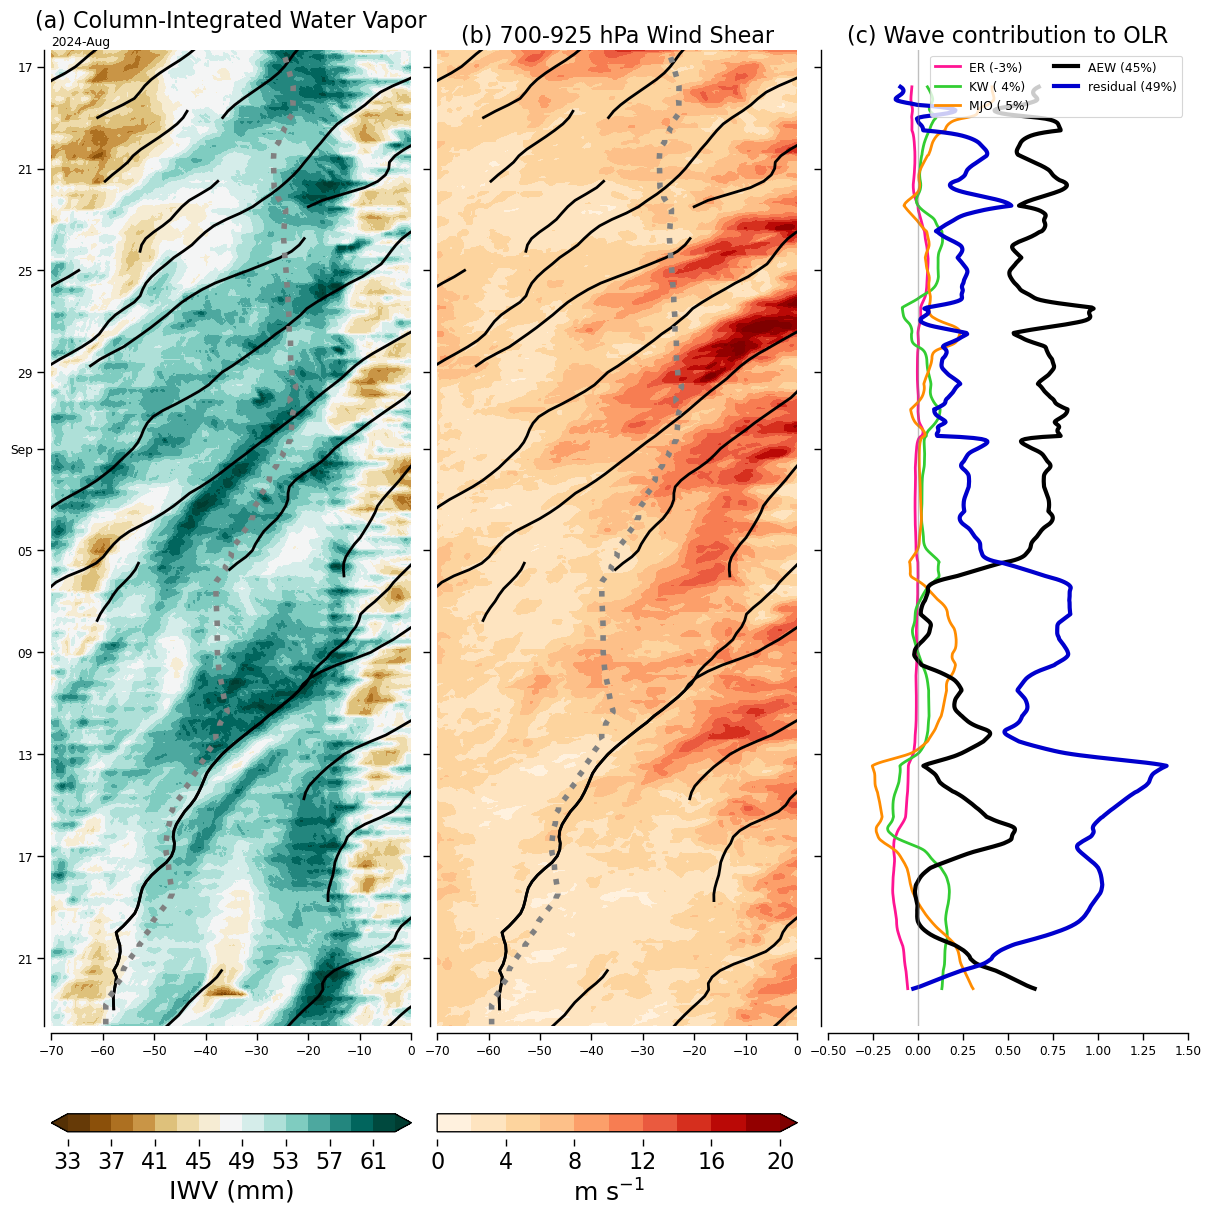

In [91]:
#colormaps
cmap_TPW = 'BrBG'
levels_TPW = np.linspace(35., 65., num=16) - 2. # centered at 48 instead of 50
levels_CIN = np.linspace(100.,500., num=5)
cmap_SST = 'ColdHot'
levels_SST = np.linspace(24,30,num=13)
cmap_CV = 'Curl'
levels_CV = np.linspace(-40,40,num=21) / 2.
levels_shear = np.array([5., 10., 15])
cmap_z200 = 'NegPos'
levels_z200 = np.linspace(-40,40,num=21)
cmap_precip = 'viridis'
levels_precip = np.linspace(0.,40.,num=21) / 20.
cmap_wspd925 = 'Boreal'
levels_wspd925 = np.linspace(2., 12.,num=11 )

#initialize plot
fig, axs = plt.subplots(1, 3, figsize=(12,12), layout="constrained")

############ column water vapor
axs[0].set_title('(a) Column-Integrated Water Vapor',fontsize=16)
c0 = axs[0].contourf( lon_TPW, datetime_hov, tpw, cmap=cmap_TPW, levels=levels_TPW, extend='both' )
axs[0].plot( lon_dship, datetime_dship, lw=4, color='Gray', alpha=1, ls=':')
cbar0 = fig.colorbar(c0, ax=axs[0], location='bottom')
cbar0.ax.tick_params(labelsize=16)
cbar0.ax.set_xlabel('IWV (mm)', fontsize=18)


############# shear
axs[1].set_title('(b) 700-925 hPa Wind Shear',fontsize=16)
cmap_SH, levels_SH = 'OrRd', np.linspace(0.,20., num=11)
c1 = axs[1].contourf( lon_ERA5, datetime_hov, shear700m925, cmap=cmap_SH, levels=levels_SH, extend='max' )
axs[1].plot( lon_dship, datetime_dship, lw=4, color='Gray', alpha=1, ls=':')
cbar1 = fig.colorbar(c1, ax=axs[1], location='bottom')
cbar1.ax.tick_params(labelsize=16)
cbar1.ax.set_xlabel(r'm s$^{-1}$', fontsize=18)

########### add AEWs
for ax_ctr, ax in enumerate(axs[:-1]):
    #ax.format( xformatter='deglon' )
    #ax.format(xlim=(-70+1e-5,0-1e-5))
    ax.set_xlim(-70.,0.)
    for ctr in range(n_aew):
        # rule out the weird AEW: # 69 which is a TC that goes backward in extratropics. Hurricane Esnesto?
            if ctr != 69:
                color = 'k'
                AEW_lat_smooth_now = AEW_lat_smooth_list[ctr]
                AEW_lon_smooth_now = AEW_lon_smooth_list[ctr]
                # AEW_lon_smooth_now[np.abs(AEW_lat_smooth_now) > 30.] = np.nan
                ax.plot( AEW_lon_smooth_list[ctr], AEW_datetime_list[ctr], lw=2, color=color, zorder=1)
    #ax.invert_xaxis()
    
axs[0].set_ylim(datetime_hov[0],datetime_hov[-1])
#axs[0].yaxis.set_major_locater(mdates.AutoDateLocator())
axs[0].yaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[0].yaxis.get_major_locator()))
#axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=18)
#axs[0].set_xticklabels(axs[0].get_xticklabels(), fontsize=18) 
axs[0].invert_yaxis()   
    
axs[1].set_ylim(datetime_hov[0],datetime_hov[-1])
#axs[1].yaxis.set_major_locater(mdates.AutoDateLocator())
axs[1].yaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[1].yaxis.get_major_locator()))
axs[1].set_yticklabels([])
#axs[1].set_xticklabels(axs[1].get_xticklabels(), fontsize=18)
axs[1].invert_yaxis()
    
########### wave contributions
axs[2].set_title('(c) Wave contribution to OLR',fontsize=16)
axs[2].plot( olr_ER_exp, datetime_wave[n_half:-n_half], lw=2, color='deeppink', label='ER ({:2.0f}%)'.format(var_ER*100.) )    
axs[2].plot( olr_KW_exp, datetime_wave[n_half:-n_half], lw=2, color='limegreen', label='KW ({:2.0f}%)'.format(var_KW*100.) )
axs[2].plot( olr_MJO_exp, datetime_wave[n_half:-n_half], lw=2, color='darkorange', label='MJO ({:2.0f}%)'.format(var_MJO*100.) )
axs[2].plot( olr_EW_exp, datetime_wave[n_half:-n_half], lw=3, color='black', label='AEW ({:2.0f}%)'.format(var_EW*100.) )
axs[2].plot( olr_residual_exp, datetime_wave[n_half:-n_half], lw=3, color='mediumblue', label='residual ({:2.0f}%)'.format(var_res*100.) )
axs[2].legend( loc='best', ncols=2)
axs[2].set_xlim(-0.5,1.5)

#add zero line
axs[2].plot( [0.,0.], [datetime_hov[0],datetime_hov[-1]], lw=1, color='gray', ls='-', alpha=0.5)

axs[2].set_ylim(datetime_hov[0],datetime_hov[-1])
#axs[2].yaxis.set_major_locater(mdates.AutoDateLocator())
axs[2].yaxis.set_major_formatter(mdates.ConciseDateFormatter(axs[2].yaxis.get_major_locator()))
axs[2].set_yticklabels([])
#axs[2].set_xticklabels(axs[2].get_xticklabels(), fontsize=18)
axs[2].invert_yaxis()

# date formatting
#for ax in axs:
    #ax.format( yformatter='%m/%d', ylocator='day' )
    #ax.format( ylim=(datetime_hov[0],datetime_hov[-1]) )

sns.set_context('paper') 
sns.despine(offset=5)
sns.despine(ax=cbar0.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar1.ax, left=True, bottom=True, right=True, top=True)

#plt.tight_layout()

# save figure
#fig.savefig(output_path_dir+'Fig_synoptic_overview.pdf', dpi=300)